# 

In [3]:
import itertools
from copy import deepcopy as copy
# from netgraph import InteactiveGraph # pip "install netgraph
from functools import reduce
from itertools import product
from operator import itemgetter

import cvxpy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy
from numpy.linalg import matrix_rank as rank
from scipy.linalg import block_diag, fractional_matrix_power
from utils.Adversary import Adversary
from utils.Conversions import hamming_dist as dist
from utils.Conversions import to_str, visualize
from utils.Problems import Problem, exact_k, threshold_k
import random
from utils.Solvers import (
    adv_solver,
    instance_mask,
    ket,
    partial,
    span_solver,
    type_mask,
)

import networkx as nx

In [75]:
def relax_peb(A, T=None, mosek=False):
    N = A.shape[0]
    if T is None:
        T = N**2
    peb = cp.Variable((T, N))
    constraints = [peb <= 1, peb >= 0, peb[-1,-1]==1, peb[0, 1:] == 0]
    for i in range(T-1):
        for v in range(N):
            for u in range(v):
                # if u is a parent of v
                if A[u,v] == 1:
                    constraints += [peb[i+1, v] <= i*peb[i, u]]
    opt_prob = cp.Problem(cp.Minimize(cp.sum(peb[:, :-1])), constraints)
    if mosek:
        opt_prob.solve(solver="MOSEK", verbose=True,  mosek_params={"MSK_IPAR_NUM_THREADS": 12})
    else:
        opt_prob.solve(solver="SCS", verbose=True)
    return peb.value

def cleanup_peb(peb, eps = 0.0001):
    time, nodes = peb.shape
    peb = np.round(peb, 5)
    for step in range(time-1, -1, -1):
        # if pebbling completed
        if np.abs(peb[step, -1] - 1) < eps:
            peb[step, :-1] = 0
        # if skipped:
        if np.linalg.norm(peb[step, :])< eps:
            peb = np.delete(peb, step, axis=0)
    # peb = np.delete(peb, 0, axis=0)
    return peb

In [76]:
def line_graph(N):
    A = np.zeros((N, N))
    for i in range(N-1):
        A[i, i+1] = 1
    return A
def complete(N):
    A = np.zeros((N,N))
    for v in range(1, N):
        for u in range(v):
            A[u,v] = 1
    return A
def argon2a(N):
    A = line_graph(N)
    for v in range(2, N):
        u = np.random.randint(v-1)
        A[u,v] = 1
    return A

def sparse_MHF(N, incoming):
    A = line_graph(N)
    incoming_nodes = random.sample(list(range(2,N)), incoming)
    print(incoming_nodes)
    for v in incoming_nodes:
        A[np.random.randint(v-1), v] = 1
    return A

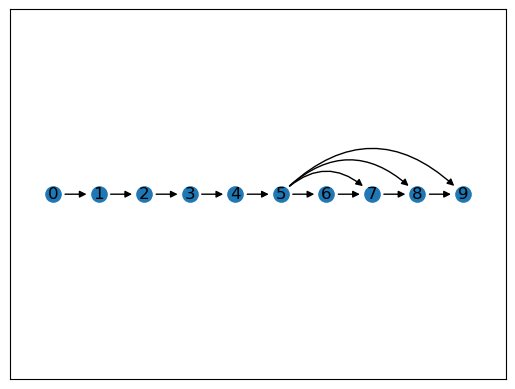

(CVXPY) Jun 13 05:29:12 PM: Your problem has 1000 variables, 3198 constraints, and 0 parameters.
(CVXPY) Jun 13 05:29:12 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 13 05:29:12 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jun 13 05:29:12 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 13 05:29:12 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jun 13 05:29:12 PM: Compiling problem (target solver=SCS).
(CVXPY) Jun 13 05:29:12 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Jun 13 05:29:12 PM: Applying reduction Dcp2Cone
(CVXPY) Jun 13 05:29:12 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jun 13 05:29:12 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jun 13 05:29:13 PM: Applying reduction SCS
(CVXPY) Jun 13 05:29:13 PM: Finished problem compilation (took 2.310e-01 seconds).
(CVXPY) Jun 13 05:29:13 PM: Invoking solver SCS  to obtain a solution.
(CVXPY) Jun 13 05:29:13 PM: Problem status: optimal
(CVXPY) Jun 13 05:29:13 PM: Optimal value: 2.073e-02
(CVXPY) Jun 13 05:29:13 PM: Compilation took 2.310e-01 seconds
(CVXPY) Jun 13 05:29:13 PM: Solver (including time spent in interface) took 2.809e-02 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.7 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 1000, constraints m: 3198
cones: 	  z: primal zero / dual free vars: 10
	  l: linear vars: 3188
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 4374, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale  | t

In [77]:
N=10
T=N**2
A = line_graph(N)
for i in range(N//2+1, N):
    A[N//2, i] = 1
    
G = nx.DiGraph(A)
pos=[(i, 0) for i in range(N)]
nx.draw_networkx_nodes(G, pos, node_size = 1200/N)
nx.draw_networkx_edges(nx.DiGraph(line_graph(N)), pos)
nx.draw_networkx_edges(nx.DiGraph(A-line_graph(N)), pos, connectionstyle="arc3, rad=-0.5")
nx.draw_networkx_labels(G, pos)
plt.show()
peb = relax_peb(A, T=T)
peb = cleanup_peb(peb)

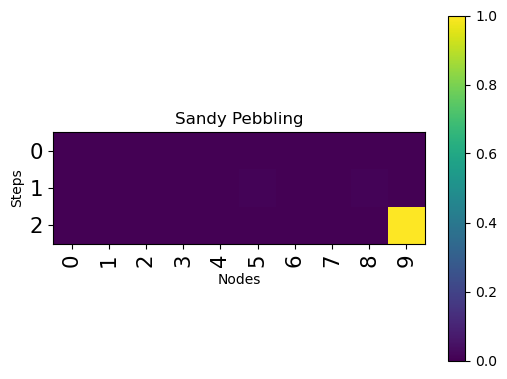

In [78]:
visualize(peb, xlabel="Nodes", ylabel="Steps", title="Sandy Pebbling", labels=(list(range(peb.shape[1])), list(range(peb.shape[0]))))